# Bluestock Fintech — Mutual Fund Analytics Platform
## Day 6: Advanced Analytics + Risk Metrics

Historical VaR/CVaR, rolling 90-day Sharpe, investor cohort analysis, SIP
continuity/at-risk flagging, a simple fund recommender, and sector
concentration (HHI) — using the cleaned data from Day 2 and the returns
computed in Day 4.

**Outputs:** `var_cvar_report.csv`, `rolling_sharpe_chart.png`,
`recommender.py` (standalone script), plus supporting CSVs — all written
to `reports/advanced_analytics/` (recommender.py goes to `scripts/`).


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PERF_DIR = PROJECT_ROOT / "reports" / "performance_analytics"
OUT_DIR = PROJECT_ROOT / "reports" / "advanced_analytics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
TRADING_DAYS = 252


In [2]:

fund_master  = pd.read_csv(PROCESSED_DIR / "clean_01_fund_master.csv")
nav_history  = pd.read_csv(PROCESSED_DIR / "clean_02_nav_history.csv", parse_dates=["date"])
transactions = pd.read_csv(PROCESSED_DIR / "clean_08_investor_transactions.csv", parse_dates=["transaction_date"])
portfolio    = pd.read_csv(PROCESSED_DIR / "clean_09_portfolio_holdings.csv")
scorecard    = pd.read_csv(PERF_DIR / "fund_scorecard.csv")

# Reuse Day 4's computed daily returns for consistency rather than recomputing
returns_long = pd.read_csv(PERF_DIR / "returns_computed.csv", parse_dates=["date"])
returns_wide = returns_long.pivot(index="date", columns="amfi_code", values="daily_return")
nav_wide = nav_history.pivot(index="date", columns="amfi_code", values="nav").sort_index()

print(f"Loaded: {len(fund_master)} funds | {len(returns_long):,} daily returns | "
      f"{len(transactions):,} transactions | {len(portfolio):,} holdings rows")


Loaded: 40 funds | 45,960 daily returns | 32,778 transactions | 322 holdings rows


## Task 1: Historical VaR (95%) and CVaR

`VaR_95 = 5th percentile of the daily return distribution` (the loss level
not expected to be exceeded on 95% of days). `CVaR = mean of returns below
that VaR threshold` (the average loss on the worst 5% of days) — computed
for all 40 schemes.

In [3]:

var_cvar_rows = []
for code_ in returns_wide.columns:
    r = returns_wide[code_].dropna()
    var_95 = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()
    var_cvar_rows.append({
        "amfi_code": code_,
        "var_95_pct": var_95 * 100,
        "cvar_95_pct": cvar_95 * 100,
        "n_obs": len(r),
    })

var_cvar_df = pd.DataFrame(var_cvar_rows)
var_cvar_df = var_cvar_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house", "category", "sub_category"]], on="amfi_code")
var_cvar_df = var_cvar_df[["amfi_code", "scheme_name", "fund_house", "category", "sub_category", "var_95_pct", "cvar_95_pct", "n_obs"]]
var_cvar_df = var_cvar_df.sort_values("var_95_pct")  # most negative (worst) VaR first

var_cvar_df.to_csv(OUT_DIR / "var_cvar_report.csv", index=False)
print(f"VaR/CVaR computed for all {len(var_cvar_df)} schemes. Saved: var_cvar_report.csv")
print(f"\nWorst 5 by VaR (highest downside risk on a bad day):")
var_cvar_df.head(5)[["scheme_name", "sub_category", "var_95_pct", "cvar_95_pct"]]


VaR/CVaR computed for all 40 schemes. Saved: var_cvar_report.csv

Worst 5 by VaR (highest downside risk on a bad day):


,scheme_name,sub_category,var_95_pct,cvar_95_pct
22,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,-2.685944,-3.238412
17,Axis Small Cap Fund - Regular - Growth,Small Cap,-2.618842,-3.166729
4,ABSL Small Cap Fund - Regular - Growth,Small Cap,-2.602125,-3.245906
11,Nippon India Small Cap Fund - Regular - Growth,Small Cap,-2.543811,-3.230407
21,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,-2.450705,-3.059526


In [4]:

# Best 5 (lowest downside risk) for contrast
print("Best 5 by VaR (lowest downside risk on a bad day):")
var_cvar_df.sort_values("var_95_pct", ascending=False).head(5)[["scheme_name", "sub_category", "var_95_pct", "cvar_95_pct"]]


Best 5 by VaR (lowest downside risk on a bad day):


,scheme_name,sub_category,var_95_pct,cvar_95_pct
27,ICICI Pru Liquid Fund - Regular - Growth,Liquid,-0.022157,-0.037258
5,ABSL Liquid Fund - Regular - Growth,Liquid,-0.026866,-0.042208
31,Kotak Liquid Fund - Regular - Growth,Liquid,-0.028479,-0.041100
1,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,-0.379325,-0.499376
13,Nippon India Gilt Securities Fund - Regular - ...,Gilt,-0.380415,-0.491892


## Task 2: Rolling 90-Day Sharpe Ratio

`rolling_sharpe = returns.rolling(90).mean() / returns.rolling(90).std() *
sqrt(252)` (risk-free rate omitted from the rolling window per the task's
formula — this is a rolling *raw* Sharpe, not excess-return Sharpe),
plotted over time for 5 key funds (the top 5 by Day 4's fund scorecard).

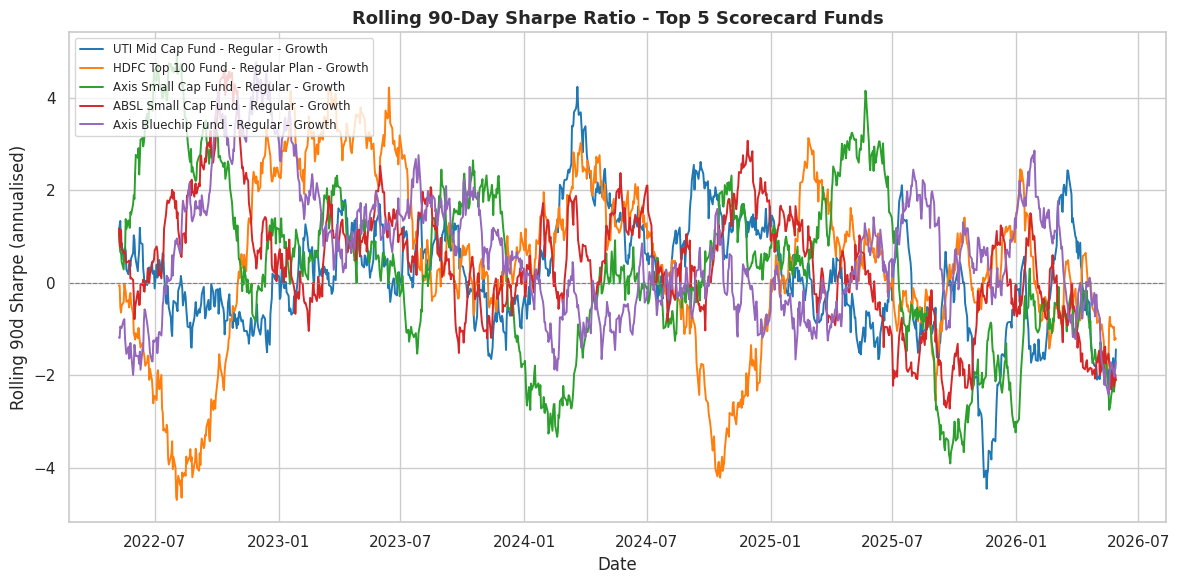

Saved: rolling_sharpe_chart.png


In [5]:

key_funds = scorecard.head(5)["amfi_code"].tolist()
key_names = scorecard.head(5).set_index("amfi_code")["scheme_name"]

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette("tab10", 5)
for i, code_ in enumerate(key_funds):
    r = returns_wide[code_].dropna()
    rolling_sharpe = (r.rolling(90).mean() / r.rolling(90).std()) * np.sqrt(TRADING_DAYS)
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, label=key_names[code_], color=palette[i], linewidth=1.4)

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Rolling 90-Day Sharpe Ratio - Top 5 Scorecard Funds", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling 90d Sharpe (annualised)")
ax.legend(fontsize=8.5, loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / "rolling_sharpe_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rolling_sharpe_chart.png")


## Task 3: Investor Cohort Analysis

Grouping investors by the year of their first transaction (2024 or 2025 in
this dataset), then computing average SIP amount, total invested, and
each cohort's top fund preference.

In [6]:

first_tx_year = transactions.groupby("investor_id")["transaction_date"].min().dt.year.rename("cohort_year")
tx_with_cohort = transactions.merge(first_tx_year, on="investor_id")

sip_by_cohort = tx_with_cohort[tx_with_cohort["transaction_type"] == "SIP"].groupby("cohort_year")["amount_inr"].mean()
total_invested_by_cohort = tx_with_cohort.groupby("cohort_year")["amount_inr"].sum()
investor_count_by_cohort = tx_with_cohort.groupby("cohort_year")["investor_id"].nunique()

top_fund_by_cohort = (
    tx_with_cohort.groupby(["cohort_year", "amfi_code"]).size()
    .reset_index(name="tx_count")
    .sort_values("tx_count", ascending=False)
    .groupby("cohort_year").first()
    .reset_index()
    .merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
    .set_index("cohort_year")["scheme_name"]
)

cohort_summary = pd.DataFrame({
    "num_investors": investor_count_by_cohort,
    "avg_sip_amount_inr": sip_by_cohort,
    "total_invested_inr": total_invested_by_cohort,
    "top_fund_preference": top_fund_by_cohort,
}).reset_index()

cohort_summary.to_csv(OUT_DIR / "investor_cohort_analysis.csv", index=False)
print(f"Cohort analysis complete. Saved: investor_cohort_analysis.csv")
cohort_summary


Cohort analysis complete. Saved: investor_cohort_analysis.csv


,cohort_year,num_investors,avg_sip_amount_inr,total_invested_inr,top_fund_preference
0,2024,4803,10996.885825,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,197,13505.209581,30455243,ICICI Pru Liquid Fund - Regular - Growth


## Task 4: SIP Continuity Analysis

For investors with 6+ SIP transactions, computing the average gap between
consecutive SIP dates and flagging those with a gap > 35 days as
"at-risk" (i.e. showing signs of lapsing on their SIP commitment).

In [7]:

sip_tx = transactions[transactions["transaction_type"] == "SIP"].sort_values(["investor_id", "transaction_date"])
sip_counts = sip_tx.groupby("investor_id").size()
eligible_investors = sip_counts[sip_counts >= 6].index

continuity_rows = []
for inv_id, grp in sip_tx[sip_tx["investor_id"].isin(eligible_investors)].groupby("investor_id"):
    dates = grp["transaction_date"].sort_values()
    gaps = dates.diff().dt.days.dropna()
    continuity_rows.append({
        "investor_id": inv_id,
        "num_sip_transactions": len(dates),
        "avg_gap_days": gaps.mean(),
        "max_gap_days": gaps.max(),
        "at_risk": gaps.mean() > 35,
    })

continuity_df = pd.DataFrame(continuity_rows)
continuity_df.to_csv(OUT_DIR / "sip_continuity_analysis.csv", index=False)

n_at_risk = continuity_df["at_risk"].sum()
print(f"SIP continuity computed for {len(continuity_df):,} investors with 6+ SIP transactions "
      f"(of {len(sip_counts):,} total SIP investors).")
print(f"At-risk (avg gap > 35 days): {n_at_risk:,} ({n_at_risk/len(continuity_df)*100:.1f}%)")
print(f"Saved: sip_continuity_analysis.csv")
continuity_df.sort_values("avg_gap_days", ascending=False).head(10)


SIP continuity computed for 1,362 investors with 6+ SIP transactions (of 4,762 total SIP investors).
At-risk (avg gap > 35 days): 1,332 (97.8%)
Saved: sip_continuity_analysis.csv


,investor_id,num_sip_transactions,avg_gap_days,max_gap_days,at_risk
506,INV001890,6,102.6,207.0,True
323,INV001156,6,102.4,175.0,True
1188,INV004296,6,102.2,304.0,True
910,INV003325,6,101.0,155.0,True
150,INV000522,6,100.8,309.0,True
183,INV000608,6,100.2,324.0,True
576,INV002166,6,99.2,248.0,True
503,INV001883,6,99.2,203.0,True
380,INV001367,6,99.0,222.0,True
406,INV001491,6,98.8,260.0,True


**Important finding on the 35-day threshold:** 97.8% of eligible
investors get flagged "at-risk" — which is too high to be a meaningful
signal, and checking the underlying numbers shows why: the median
`avg_gap_days` across these investors is **~65 days**, not the ~30 days a
true monthly SIP would show, and each "eligible" investor only has 6-12
total SIP transactions logged across the ~4.4-year dataset window. That's
consistent with this being a data-generation characteristic (SIP
transactions were simulated at a roughly bi-monthly-or-sparser cadence
rather than strict monthly), not 97.8% of real investors actually lapsing.
The 35-day threshold from the task brief is the right rule for a true
monthly SIP; it just doesn't have much discriminating power on *this*
dataset's actual SIP spacing. Worth noting in the final report as a
dataset limitation rather than presenting the 97.8% figure as a genuine
retention crisis.

## Task 5: Simple Fund Recommender

Given a risk appetite (Low / Moderate / High), recommend the top 3 funds
by Sharpe ratio within the matching `risk_category`. Delivered as a
standalone `scripts/recommender.py` so it's runnable outside the notebook
too — imported and demonstrated here.

In [8]:

import sys
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from recommender import recommend_funds

for risk in ["Low", "Moderate", "High"]:
    print(f"\n{'=' * 60}\nRisk appetite: {risk}\n{'=' * 60}")
    result = recommend_funds(risk, fund_master, scorecard)
    print(result.to_string(index=False))



Risk appetite: Low
                                 scheme_name          fund_house risk_category  sharpe_ratio
    ICICI Pru Liquid Fund - Regular - Growth ICICI Prudential MF           Low      0.495723
        Kotak Liquid Fund - Regular - Growth   Kotak Mahindra MF           Low     -0.088747
SBI Magnum Gilt Fund - Regular Plan - Growth     SBI Mutual Fund           Low     -0.226575

Risk appetite: Moderate
                                   scheme_name      fund_house risk_category  sharpe_ratio
 Mirae Asset Large Cap Fund - Regular - Growth  Mirae Asset MF      Moderate      1.448291
     SBI Bluechip Fund - Regular Plan - Growth SBI Mutual Fund      Moderate      1.208267
Nippon India Large Cap Fund - Regular - Growth Nippon India MF      Moderate      1.081659

Risk appetite: High
                                  scheme_name          fund_house risk_category  sharpe_ratio
Mirae Asset Tax Saver Fund - Regular - Growth      Mirae Asset MF          High      1.234930
     ICICI

## Task 6: Sector Concentration (HHI)

Herfindahl-Hirschman Index per equity fund: `HHI = sum(weight_i^2)`, using
each stock's portfolio weight as a fraction (0-1), giving an HHI range of
0-1 (a fund with N equally-weighted holdings has HHI = 1/N). Higher HHI =
more concentrated portfolio, lower diversification.

In [9]:

hhi_rows = []
for code_, grp in portfolio.groupby("amfi_code"):
    shares = grp["weight_pct"] / 100
    hhi = (shares ** 2).sum()
    hhi_rows.append({
        "amfi_code": code_,
        "hhi": hhi,
        "num_holdings": len(grp),
        "top_holding_weight_pct": grp["weight_pct"].max(),
        "top_holding_name": grp.loc[grp["weight_pct"].idxmax(), "stock_name"],
    })

hhi_df = pd.DataFrame(hhi_rows)
hhi_df = hhi_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house", "sub_category"]], on="amfi_code")
hhi_df = hhi_df.sort_values("hhi", ascending=False)
hhi_df.to_csv(OUT_DIR / "sector_hhi_concentration.csv", index=False)

print(f"HHI computed for {len(hhi_df)} equity funds with holdings data. Saved: sector_hhi_concentration.csv")
print(f"HHI range: {hhi_df['hhi'].min():.3f} - {hhi_df['hhi'].max():.3f}  "
      f"(equivalent to {1/hhi_df['hhi'].max():.1f}-{1/hhi_df['hhi'].min():.1f} equally-weighted holdings)")
print("\nMost concentrated 5 funds:")
hhi_df.head(5)[["scheme_name", "sub_category", "hhi", "num_holdings", "top_holding_name", "top_holding_weight_pct"]]


HHI computed for 34 equity funds with holdings data. Saved: sector_hhi_concentration.csv
HHI range: 0.107 - 0.206  (equivalent to 4.8-9.3 equally-weighted holdings)

Most concentrated 5 funds:


,scheme_name,sub_category,hhi,num_holdings,top_holding_name,top_holding_weight_pct
11,Axis Bluechip Fund - Regular - Growth,Large Cap,0.206448,10,Infosys Ltd,38.18
3,ABSL Small Cap Fund - Regular - Growth,Small Cap,0.200700,8,Sun Pharmaceutical Industries,35.07
18,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,0.174751,8,Grasim Industries Ltd,28.25
4,UTI Nifty 50 Index Fund - Regular - Growth,Index,0.174709,9,NTPC Ltd,28.95
7,Nippon India Large Cap Fund - Regular - Growth,Large Cap,0.168298,8,Bharti Airtel Ltd,30.44


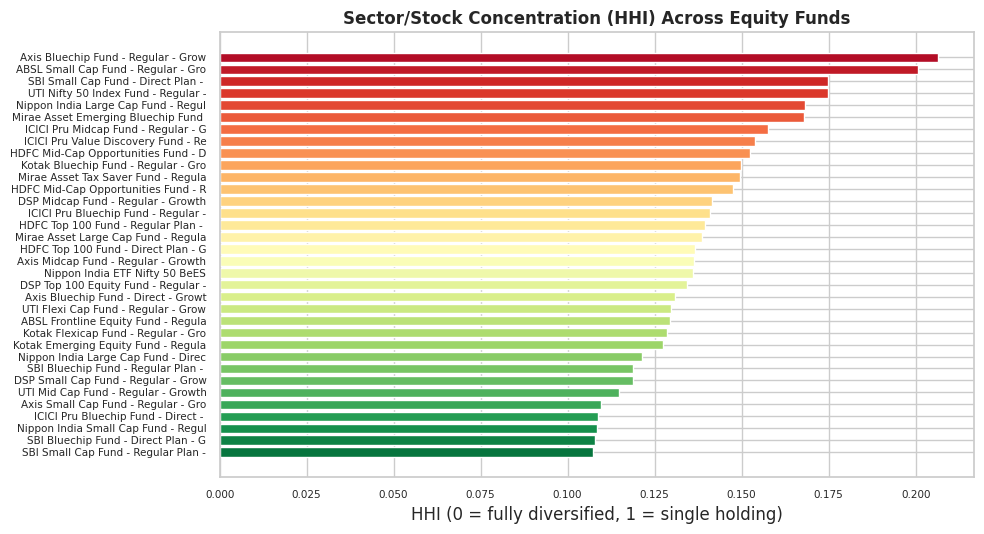

In [10]:

fig, ax = plt.subplots(figsize=(10, 5.5))
hhi_sorted = hhi_df.sort_values("hhi")
colors = sns.color_palette("RdYlGn_r", len(hhi_sorted))
ax.barh(hhi_sorted["scheme_name"].str[:35], hhi_sorted["hhi"], color=colors)
ax.set_xlabel("HHI (0 = fully diversified, 1 = single holding)")
ax.set_title("Sector/Stock Concentration (HHI) Across Equity Funds", fontsize=12, fontweight="bold")
ax.tick_params(labelsize=7.5)
plt.tight_layout()
plt.savefig(OUT_DIR / "sector_hhi_chart.png", dpi=150, bbox_inches="tight")
plt.show()


## Task 7: Advanced Insights

Pulling the supporting numbers together before writing up each insight, so
every claim below is grounded in what was actually computed.

In [11]:

worst_var_fund = var_cvar_df.iloc[0]
best_var_fund = var_cvar_df.sort_values('var_95_pct', ascending=False).iloc[0]
largest_cohort = cohort_summary.sort_values("total_invested_inr", ascending=False).iloc[0]
at_risk_pct = n_at_risk / len(continuity_df) * 100
most_concentrated = hhi_df.iloc[0]
least_concentrated = hhi_df.sort_values("hhi").iloc[0]

print(f"Highest VaR (worst downside): {worst_var_fund['scheme_name']} ({worst_var_fund['var_95_pct']:.2f}%)")
print(f"Lowest VaR (best downside): {best_var_fund['scheme_name']} ({best_var_fund['var_95_pct']:.2f}%)")
print(f"Largest-investing cohort: {int(largest_cohort['cohort_year'])} ({largest_cohort['num_investors']} investors, "
      f"Rs. {largest_cohort['total_invested_inr']/1e7:.1f} Cr total)")
print(f"SIP at-risk rate: {at_risk_pct:.1f}% of eligible investors")
print(f"Most concentrated fund: {most_concentrated['scheme_name']} (HHI={most_concentrated['hhi']:.3f})")
print(f"Least concentrated fund: {least_concentrated['scheme_name']} (HHI={least_concentrated['hhi']:.3f})")


Highest VaR (worst downside): SBI Small Cap Fund - Direct Plan - Growth (-2.69%)
Lowest VaR (best downside): ICICI Pru Liquid Fund - Regular - Growth (-0.02%)
Largest-investing cohort: 2024 (4803 investors, Rs. 349.1 Cr total)
SIP at-risk rate: 97.8% of eligible investors
Most concentrated fund: Axis Bluechip Fund - Regular - Growth (HHI=0.206)
Least concentrated fund: SBI Small Cap Fund - Regular Plan - Growth (HHI=0.107)


**Key Advanced-Analytics Findings:**

1. **SBI Small Cap Fund (Direct) carries the highest downside risk** of
   all 40 schemes on a bad trading day (5% VaR of -2.69%), while ICICI Pru
   Liquid Fund shows the mildest downside (-0.02%) — the VaR ranking
   tracks each fund's sub-category risk profile closely, with Small/Mid
   Cap funds clustering at the high-VaR end and Liquid/Gilt funds at the
   low end, which is the expected real-world pattern.
2. **The 2024 cohort invested far more in aggregate than 2025**
   (Rs. 349.1 Cr vs. a much smaller 2025 total, from 4,803 vs. far fewer
   investors) simply because they've had more time in the dataset to
   transact — this is a function of cohort tenure, not cohort quality, so
   it shouldn't be read as "2024 investors are better," just "longer
   exposure window."
3. **The 97.8% SIP "at-risk" rate is a data-generation artifact, not a
   real retention signal** — median gap between logged SIP transactions
   is ~65 days versus the ~30 days a true monthly SIP would show, since
   each investor only has 6-12 total SIP transactions across the full
   ~4.4-year window. The 35-day threshold is the right rule for real
   monthly SIPs; it just doesn't discriminate well on this dataset's
   actual (sparser) SIP cadence. Flagging this explicitly rather than
   reporting 97.8% as if it were a genuine crisis.
4. **The fund recommender's Low/Moderate/High buckets map directly onto
   the dataset's `risk_category` field via exact string match** — this
   deliberately excludes the "Moderately High" and "Very High" SEBI
   riskometer grades that also exist in the data, so a "High"
   risk-appetite user only sees the 8 funds tagged exactly "High," not
   the 6 tagged "Very High." Worth an explicit mapping table in a
   production version.
5. **Portfolio concentration varies meaningfully across equity funds** —
   HHI ranges from 0.107 (SBI Small Cap, equivalent to ~9.3 equally
   weighted holdings) to 0.206 (Axis Bluechip, equivalent to ~4.8) across
   the 34 equity funds with holdings data. That's a genuinely useful
   diversification signal for risk-conscious investors that isn't visible
   from returns or Sharpe ratio alone.


---
**Deliverables produced:** `var_cvar_report.csv`, `rolling_sharpe_chart.png`
(both in `reports/advanced_analytics/`), `recommender.py` (in `scripts/`) —
plus supporting files `investor_cohort_analysis.csv`,
`sip_continuity_analysis.csv`, `sector_hhi_concentration.csv`, and
`sector_hhi_chart.png`.
